In [1]:
result_path = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/two_talker_pilot_v01/preston_pilot.csv'
exp_manifest_path = '/om2/user/rphess/Auditory-Attention/preston_pilot_exp.pkl'

In [21]:
import pickle as pkl
import pandas as pd
import numpy as np

In [3]:
with open(exp_manifest_path, 'rb') as f:
    exp_manifest = pkl.load(f)

In [4]:
exp_manifest

{'block_0': {'trial_0': {'target_loc': (30, 0),
   'distractor_loc': (70, 40),
   'sex_cond': 'male_male',
   'crossed': False,
   'azim_delta': 40,
   'elev_delta': 40,
   'target_word': 'students',
   'distractor_word': 'twenty'},
  'trial_1': {'target_loc': (-20, 10),
   'distractor_loc': (-20, 20),
   'sex_cond': 'male_female',
   'crossed': False,
   'azim_delta': 0,
   'elev_delta': 10,
   'target_word': 'appear',
   'distractor_word': 'black'},
  'trial_2': {'target_loc': (-40, 30),
   'distractor_loc': (-60, -10),
   'sex_cond': 'female_male',
   'crossed': False,
   'azim_delta': -20,
   'elev_delta': -40,
   'target_word': 'travel',
   'distractor_word': 'worked'},
  'trial_3': {'target_loc': (0, 10),
   'distractor_loc': (40, 20),
   'sex_cond': 'male_female',
   'crossed': False,
   'azim_delta': 40,
   'elev_delta': 10,
   'target_word': 'complete',
   'distractor_word': 'complex'},
  'trial_4': {'target_loc': (-90, -20),
   'distractor_loc': (-10, 20),
   'sex_cond': 'fem

In [34]:
exp_results = pd.read_csv(result_path)

In [35]:
trials = exp_results[exp_results['trial_type'] == 'dictionary-text']

In [36]:
trials.reset_index(inplace=True)

In [37]:
trials = trials.drop(['index', 'Unnamed: 0', 'response_str', 'trial_type', 'internal_node_id', 'stimulus'], axis=1)

In [19]:
exp_manifest

{'block_0': {'trial_0': {'target_loc': (30, 0),
   'distractor_loc': (70, 40),
   'sex_cond': 'male_male',
   'crossed': False,
   'azim_delta': 40,
   'elev_delta': 40,
   'target_word': 'students',
   'distractor_word': 'twenty'},
  'trial_1': {'target_loc': (-20, 10),
   'distractor_loc': (-20, 20),
   'sex_cond': 'male_female',
   'crossed': False,
   'azim_delta': 0,
   'elev_delta': 10,
   'target_word': 'appear',
   'distractor_word': 'black'},
  'trial_2': {'target_loc': (-40, 30),
   'distractor_loc': (-60, -10),
   'sex_cond': 'female_male',
   'crossed': False,
   'azim_delta': -20,
   'elev_delta': -40,
   'target_word': 'travel',
   'distractor_word': 'worked'},
  'trial_3': {'target_loc': (0, 10),
   'distractor_loc': (40, 20),
   'sex_cond': 'male_female',
   'crossed': False,
   'azim_delta': 40,
   'elev_delta': 10,
   'target_word': 'complete',
   'distractor_word': 'complex'},
  'trial_4': {'target_loc': (-90, -20),
   'distractor_loc': (-10, 20),
   'sex_cond': 'fem

In [32]:
target_loc = []
distractor_loc = []
sex_cond = []
crossed = []
azim_delta = []
elev_delta = []
distractor_word = []
for block in exp_manifest.values():
    for trial in block.values():
        target_loc.append(trial['target_loc'])
        distractor_loc.append(trial['distractor_loc'])
        sex_cond.append(trial['sex_cond'])
        crossed.append(trial['crossed'])
        azim_delta.append(trial['azim_delta'])
        elev_delta.append(trial['elev_delta'])
        distractor_word.append(trial['distractor_word'])

In [39]:
trials['target_loc'] = target_loc
trials['distractor_loc'] = distractor_loc
trials['sex_cond'] = sex_cond
trials['crossed'] = crossed
trials['azim_delta'] = azim_delta
trials['elev_delta'] = elev_delta
trials['distractor_word'] = distractor_word

In [40]:
trials

,rt,response,correct_response,trial_num,trial_index,time_elapsed,correct,n_correct,n_incorrect,target_loc,distractor_loc,sex_cond,crossed,azim_delta,elev_delta,distractor_word
0,33746,students,students,0.0,0,33748,1.0,1.0,0.0,"(30, 0)","(70, 40)",male_male,False,40,40,twenty
1,10490,appear,appear,1.0,2,46805,1.0,2.0,0.0,"(-20, 10)","(-20, 20)",male_female,False,0,10,black
2,9338,travel,travel,2.0,4,57269,1.0,3.0,0.0,"(-40, 30)","(-60, -10)",female_male,False,-20,-40,worked
3,10722,complete,complete,3.0,6,69002,1.0,4.0,0.0,"(0, 10)","(40, 20)",male_female,False,40,10,complex
4,8479,hundred,groups,4.0,8,78705,0.0,4.0,1.0,"(-90, -20)","(-10, 20)",female_male,False,80,40,players
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,8140,played,played,355.0,710,4719561,1.0,269.0,87.0,"(-50, 40)","(-70, 0)",female_female,False,-20,-40,video
356,13575,matter,matter,356.0,712,4734328,1.0,270.0,87.0,"(90, -10)","(50, -20)",male_male,False,-40,-10,parish
357,8422,released,released,357.0,714,4744075,1.0,271.0,87.0,"(-50, 10)","(-40, 20)",male_female,False,10,10,internet
358,13273,light,light,358.0,716,4758242,1.0,272.0,87.0,"(70, 10)","(70, 0)",female_female,False,0,-10,evidence


In [45]:
import seaborn as sns

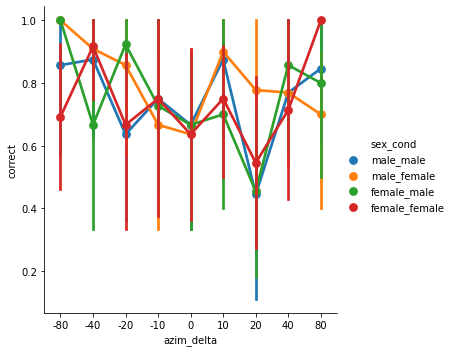

In [48]:
sns.catplot(data=trials, x='azim_delta', y='correct', kind='point', hue='sex_cond')

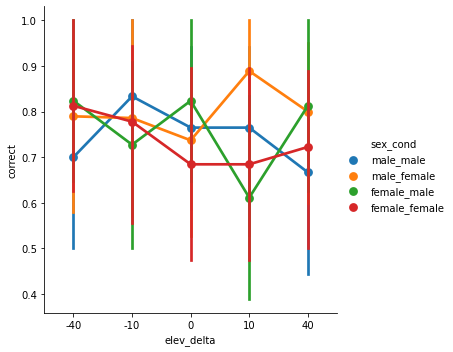

In [49]:
sns.catplot(data=trials, x='elev_delta', y='correct', kind='point', hue='sex_cond')

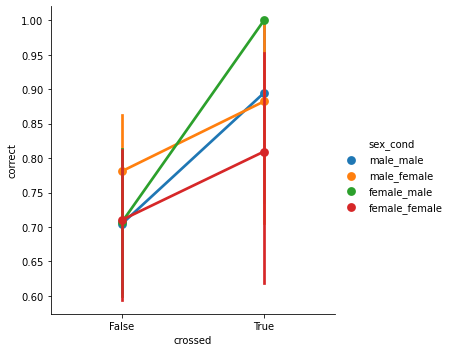

In [52]:
sns.catplot(data=trials, x='crossed', y='correct', kind='point', hue='sex_cond')